In [ ]:
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 4.4 MB/s eta 0:00:00


In [ ]:
import os, random
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import shap
from collections import Counter
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from scipy.stats import randint, uniform
from imblearn.over_sampling import SMOTE
from tensorflow.keras.optimizers import Adam
from sklearn.compose import ColumnTransformer
from category_encoders import CatBoostEncoder
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.feature_selection import SelectFromModel
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.utils.class_weight import compute_sample_weight, compute_class_weight
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.metrics import classification_report, confusion_matrix, f1_score as f1
from sklearn.model_selection import (GridSearchCV, RandomizedSearchCV,
                                     StratifiedKFold, cross_val_score, train_test_split)

In [ ]:
SEED = 7
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
tf.config.experimental.enable_op_determinism()

In [ ]:
'''from google.colab import files
uploaded = files.upload()'''

'from google.colab import files\nuploaded = files.upload()'

In [ ]:
pregnant_women = pd.read_excel("Project data (cleaned).xlsx")

In [ ]:
pregnant_women.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1132 entries, 0 to 1131
Data columns (total 21 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   age_group                   1132 non-null   object
 1   region                      1132 non-null   object
 2   type_of_residence           1132 non-null   object
 3   currently_breastfeeding     1132 non-null   object
 4   marital_status              1132 non-null   object
 5   currently_working           1132 non-null   object
 6   total_children_ever_born    1132 non-null   int64 
 7   births_in_the_last_5_years  1132 non-null   int64 
 8   BMI                         1132 non-null   int64 
 9   birth_interval              1132 non-null   object
 10  anaemia_level               1132 non-null   object
 11  education_level             1132 non-null   object
 12  wealth_index                1132 non-null   object
 13  religion                    1132 non-null   obje

### BMI Conversion
BMI is stored as integer × 100 in the source file (e.g. 1923 = 19.23 kg/m²). Divide by 100 to get correct float values.

In [ ]:
pregnant_women['BMI'] = pregnant_women['BMI'] / 100

### Checking Skewness of Numerical Features

In [ ]:
print("BMI skew:                      ", pregnant_women['BMI'].skew())
print("total_children_ever_born skew: ", pregnant_women['total_children_ever_born'].skew())
print("births_in_last_5_years skew:   ", pregnant_women['births_in_the_last_5_years'].skew())
print("antenatal_visits skew:         ", pregnant_women['antenatal_visits'].skew())

BMI skew:                       1.6458452856127215
total_children_ever_born skew:  0.9948700053444631
births_in_last_5_years skew:    0.2580636225775612
antenatal_visits skew:          9.648144039238938


### Dealing with Outliers


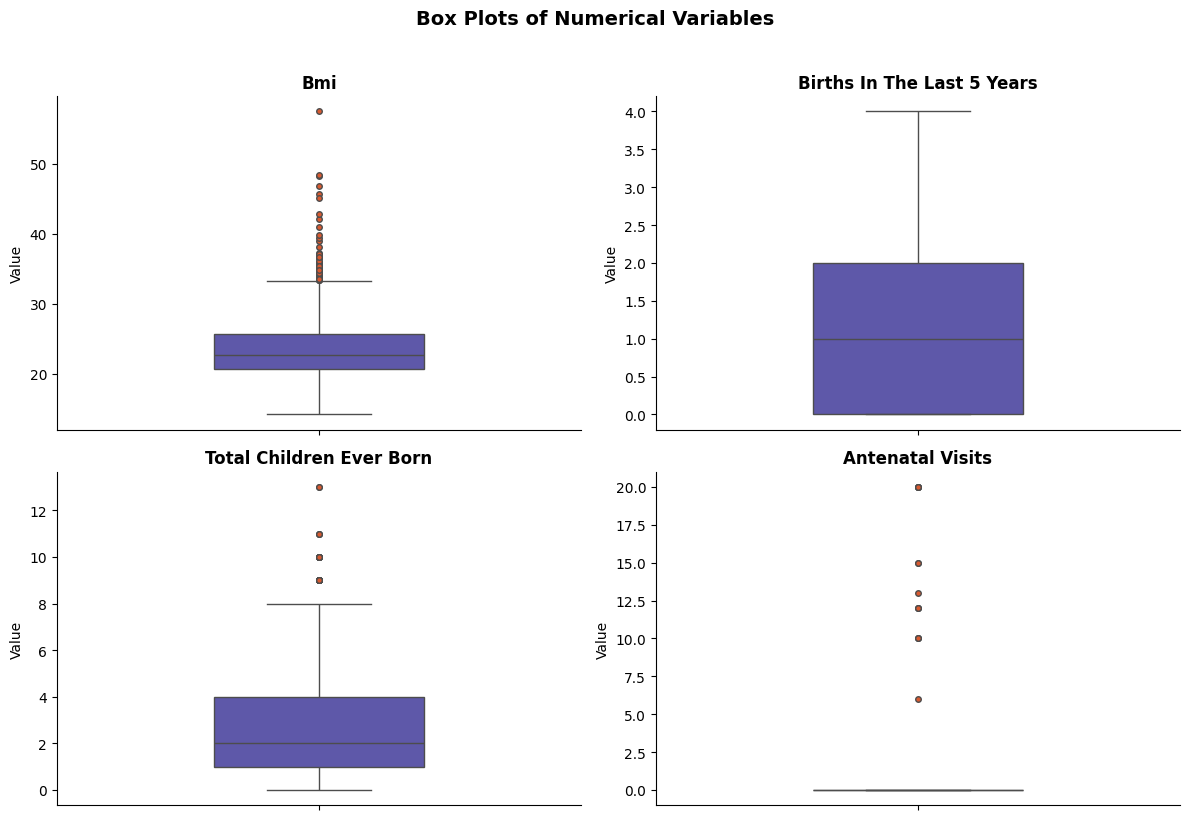

In [ ]:
numerical_cols = [
    "BMI",
    "births_in_the_last_5_years",
    "total_children_ever_born",
    "antenatal_visits"
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=pregnant_women[col], ax=axes[i], color="#534AB7", width=0.4,
                flierprops=dict(marker='o', markerfacecolor='#D85A30', markersize=4))
    axes[i].set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Value")
    axes[i].spines[["top", "right"]].set_visible(False)

plt.suptitle("Box Plots of Numerical Variables", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
outlier_cols= [
    "BMI",
    "births_in_the_last_5_years",
    "total_children_ever_born"
]

for col in outlier_cols:

    # Calculate quartiles
    Q1 = pregnant_women[col].quantile(0.25)
    Q3 = pregnant_women[col].quantile(0.75)

    # Compute IQR
    IQR = Q3 - Q1

    # Define limits
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Replace outliers using capping
    pregnant_women[col] = np.where(pregnant_women[col] < lower_bound, lower_bound, pregnant_women[col])

    pregnant_women[col] = np.where(pregnant_women[col] > upper_bound, upper_bound, pregnant_women[col])

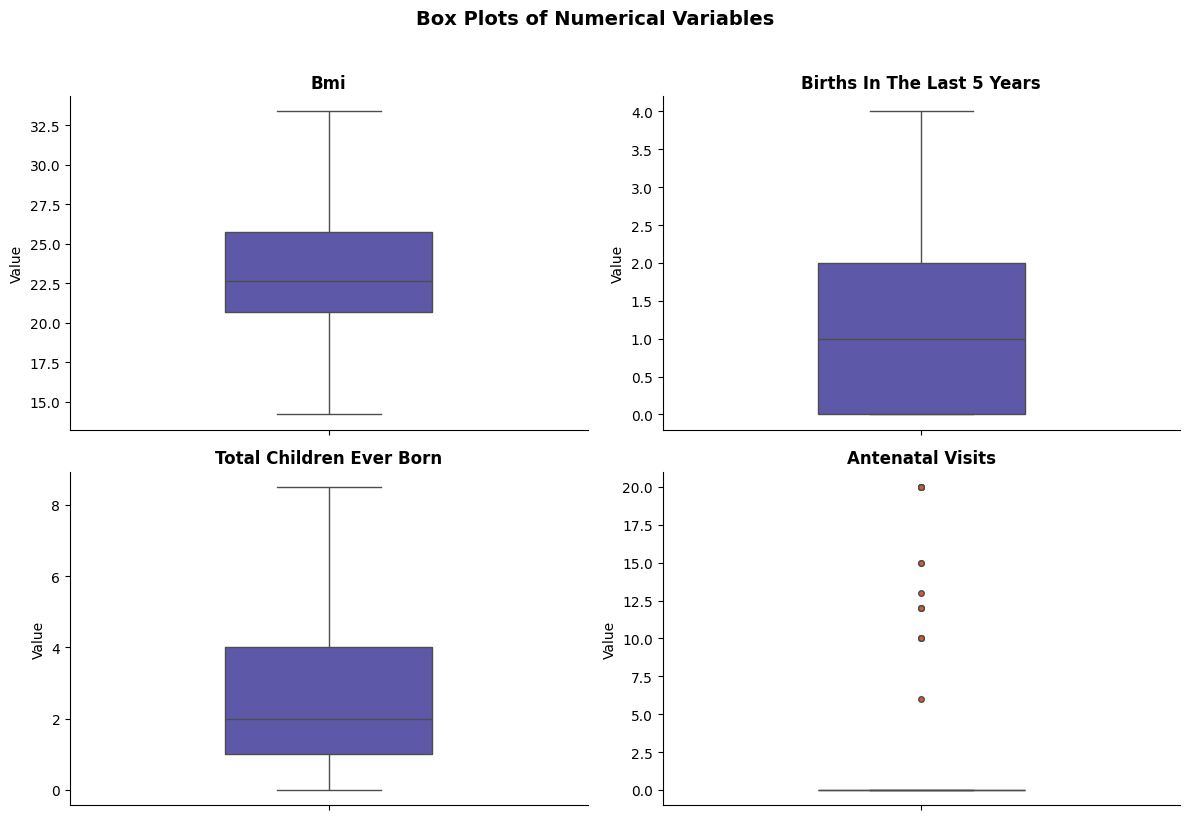

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(y=pregnant_women[col], ax=axes[i], color="#534AB7", width=0.4,
                flierprops=dict(marker='o', markerfacecolor='#D85A30', markersize=4))
    axes[i].set_title(col.replace("_", " ").title(), fontsize=12, fontweight="bold")
    axes[i].set_ylabel("Value")
    axes[i].spines[["top", "right"]].set_visible(False)

plt.suptitle("Box Plots of Numerical Variables", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("BMI skew:                      ", pregnant_women['BMI'].skew())
print("total_children_ever_born skew: ", pregnant_women['total_children_ever_born'].skew())
print("births_in_last_5_years skew:   ", pregnant_women['births_in_the_last_5_years'].skew())
print("antenatal_visits skew:         ", pregnant_women['antenatal_visits'].skew())

BMI skew:                       0.7054587391290943
total_children_ever_born skew:  0.7483911154303512
births_in_last_5_years skew:    0.2580636225775612
antenatal_visits skew:          9.648144039238938


### Descriptive Statistics

In [ ]:
pregnant_women.describe(include='object')

,age_group,region,type_of_residence,currently_breastfeeding,marital_status,currently_working,birth_interval,anaemia_level,education_level,wealth_index,religion,ethnicity,freq_of_reading_newspapers,freq_of_listening_to_radio,freq_of_watching_TV,had_STI_last_12months,currently_pregnant
count,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132,1132
unique,7,6,2,2,2,2,4,4,4,5,5,122,3,3,3,2,1
top,25-29,North west,Rural,No,Married,Yes,Medium interval,Not anemic,No education,Poorest,Islam,Hausa,Not at all,Not at all,Not at all,No,Yes
freq,332,316,692,1104,1052,607,444,548,459,275,643,344,1030,671,688,1029,1132


In [ ]:
pregnant_women.describe()

,total_children_ever_born,births_in_the_last_5_years,BMI,antenatal_visits
count,1132.000000,1132.000000,1132.000000,1132.000000
mean,2.730565,1.057420,23.484142,0.189929
std,2.211981,0.794136,4.051680,1.720055
min,0.000000,0.000000,14.190000,0.000000
25%,1.000000,0.000000,20.650000,0.000000
50%,2.000000,1.000000,22.625000,0.000000
75%,4.000000,2.000000,25.732500,0.000000
max,8.500000,4.000000,33.356250,20.000000


In [ ]:
pregnant_women.dropna(inplace=True)

### EDA Charts

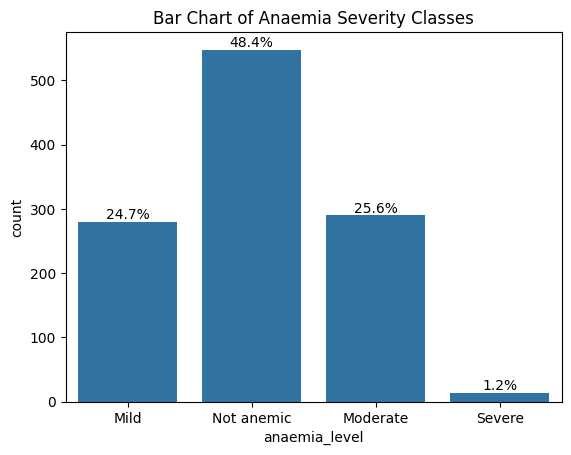

In [ ]:
anaemia_percentages = pregnant_women['anaemia_level'].value_counts(normalize=True)*100
ax = sns.countplot(x='anaemia_level', data=pregnant_women)
for p in ax.patches:
    cat = p.get_x() + p.get_width()/2
    h   = p.get_height()
    lbl = ax.get_xticklabels()[int(cat)].get_text()
    ax.annotate(f'{anaemia_percentages[lbl]:.1f}%', (p.get_x()+p.get_width()/2, h), ha='center', va='bottom')
plt.title("Bar Chart of Anaemia Severity Classes"); plt.show()

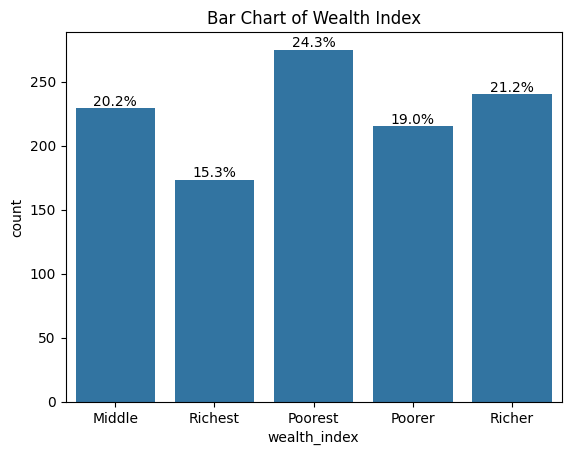

In [ ]:
wealth_percentages = pregnant_women['wealth_index'].value_counts(normalize=True)*100
ax = sns.countplot(x='wealth_index', data=pregnant_women)
for p in ax.patches:
    cat = p.get_x() + p.get_width()/2
    h   = p.get_height()
    lbl = ax.get_xticklabels()[int(cat)].get_text()
    ax.annotate(f'{wealth_percentages[lbl]:.1f}%', (p.get_x()+p.get_width()/2, h), ha='center', va='bottom')
plt.title("Bar Chart of Wealth Index"); plt.show()

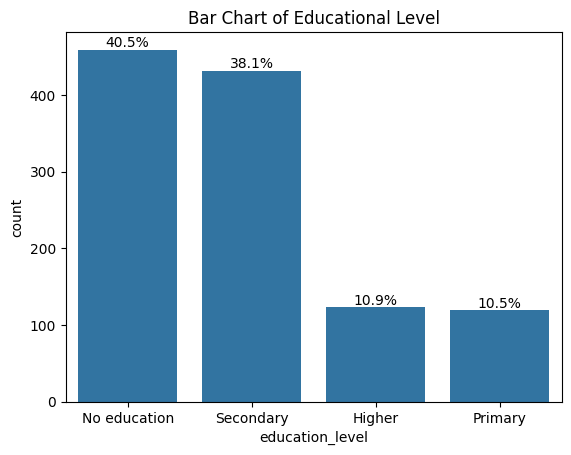

In [ ]:
education_percentages = pregnant_women['education_level'].value_counts(normalize=True)*100
ax = sns.countplot(x='education_level', data=pregnant_women)
for p in ax.patches:
    cat = p.get_x() + p.get_width()/2
    h   = p.get_height()
    lbl = ax.get_xticklabels()[int(cat)].get_text()
    ax.annotate(f'{education_percentages[lbl]:.1f}%', (p.get_x()+p.get_width()/2, h), ha='center', va='bottom')
plt.title("Bar Chart of Educational Level"); plt.show()

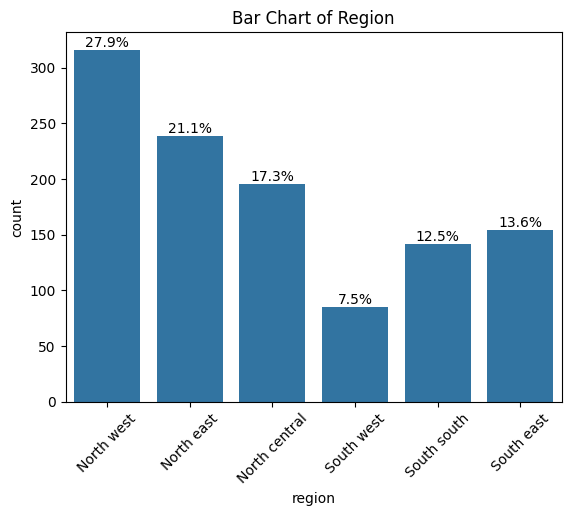

In [ ]:
region_percentages = pregnant_women['region'].value_counts(normalize=True)*100
ax = sns.countplot(x='region', data=pregnant_women)
for p in ax.patches:
    cat = p.get_x() + p.get_width()/2
    h   = p.get_height()
    lbl = ax.get_xticklabels()[int(cat)].get_text()
    ax.annotate(f'{region_percentages[lbl]:.1f}%', (p.get_x()+p.get_width()/2, h), ha='center', va='bottom')
plt.title("Bar Chart of Region"); plt.xticks(rotation=45); plt.show()

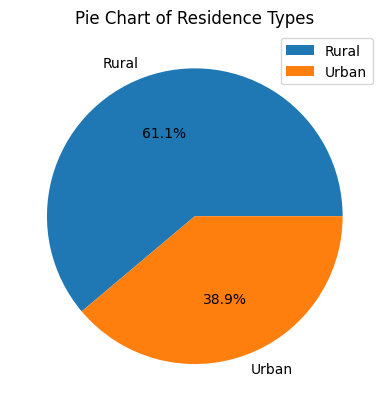

In [ ]:
residence_percentages = pregnant_women['type_of_residence'].value_counts()
plt.pie(residence_percentages, labels=['Rural','Urban'], autopct='%1.1f%%')
plt.title('Pie Chart of Residence Types'); plt.legend(); plt.show()

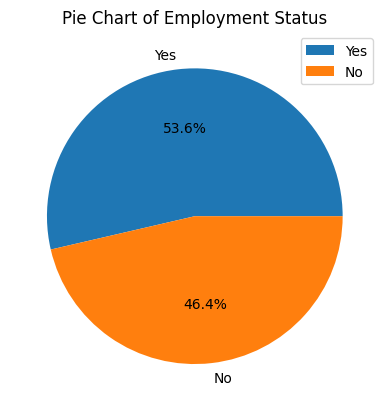

In [ ]:
employment_percentages = pregnant_women['currently_working'].value_counts()
plt.pie(employment_percentages, labels=['Yes','No'], autopct='%1.1f%%')
plt.title('Pie Chart of Employment Status'); plt.legend(); plt.show()

### Encode Target Variable

In [ ]:
anaemia_severity = {'Not anemic': 0, 'Mild': 1, 'Moderate': 2, 'Severe': 3}
pregnant_women['anaemia_level'] = pregnant_women['anaemia_level'].map(anaemia_severity)

### Correlation Matrix of Numerical Variables

In [ ]:
numeric_df = pregnant_women[['total_children_ever_born','births_in_the_last_5_years',
                               'BMI', 'anaemia_level', 'antenatal_visits']]
numeric_df.corr()

,total_children_ever_born,births_in_the_last_5_years,BMI,anaemia_level,antenatal_visits
total_children_ever_born,1.000000,0.409473,0.027447,0.054971,-0.000249
births_in_the_last_5_years,0.409473,1.000000,-0.005197,-0.040898,0.073568
BMI,0.027447,-0.005197,1.000000,-0.085117,0.056821
anaemia_level,0.054971,-0.040898,-0.085117,1.000000,0.002188
antenatal_visits,-0.000249,0.073568,0.056821,0.002188,1.000000


### X and Y Variables
`currently_pregnant` is constant (always 'Yes') — dropped as a zero-variance feature.

In [ ]:
X = pregnant_women.drop(['anaemia_level', 'currently_pregnant'], axis=1)
Y = pregnant_women['anaemia_level']
Y.value_counts(normalize=True)

,proportion
anaemia_level,
0,0.484099
2,0.256184
1,0.247350
3,0.012367


### Train / Test Split (80-20)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y, random_state=42
)
print("Train class distribution:"); print(y_train.value_counts(normalize=True))
print("Test class distribution:");  print(y_test.value_counts(normalize=True))

Train class distribution:
anaemia_level
0    0.483978
2    0.256354
1    0.247514
3    0.012155
Name: proportion, dtype: float64
Test class distribution:
anaemia_level
0    0.484581
2    0.255507
1    0.246696
3    0.013216
Name: proportion, dtype: float64


### Preprocessing Setup

Ordinal columns are mapped manually then fed into the pipeline.
Log transformation is applied **inside the pipeline** via `FunctionTransformer`
so it is consistently applied during cross-validation (no data leakage).
Two preprocessors are defined:
- `preprocessor` — for Logistic Regression and ANN (includes StandardScaler)
- `rf_preprocessor` — for Random Forest and XGBoost (no scaling needed for tree models)


In [ ]:
# --- Manual ordinal encoding ---
birth_interval_order = {'No previous birth': 0, 'Short interval': 1, 'Medium interval': 2, 'Long interval': 3}
education_level_order = {'No education': 0, 'Primary': 1, 'Secondary': 2, 'Higher': 3}
wealth_index_order = {'Poorest': 0, 'Poorer': 1, 'Middle': 2, 'Richer': 3, 'Richest': 4}
media_order = {'Not at all': 0, 'Less than once a week': 1, 'At least once a week': 2}

def encode_ordinals(df):
    df = df.copy()
    df['birth_interval']             = df['birth_interval'].map(birth_interval_order)
    df['education_level']            = df['education_level'].map(education_level_order)
    df['wealth_index']               = df['wealth_index'].map(wealth_index_order)
    df['freq_of_reading_newspapers'] = df['freq_of_reading_newspapers'].map(media_order)
    df['freq_of_listening_to_radio'] = df['freq_of_listening_to_radio'].map(media_order)
    df['freq_of_watching_TV']        = df['freq_of_watching_TV'].map(media_order)
    return df

X_train_copy = encode_ordinals(X_train)
X_test_copy  = encode_ordinals(X_test)

In [ ]:
# --- Column groups ---
numeric_cols      = ['BMI', 'total_children_ever_born','births_in_the_last_5_years', 'antenatal_visits']
low_card_cat_cols = ['age_group', 'region', 'type_of_residence', 'religion', 'had_STI_last_12months',
                     'currently_breastfeeding','marital_status', 'currently_working']
high_card_cat_col = ['ethnicity']
ordinal_cols      = ['birth_interval', 'education_level', 'wealth_index',
                     'freq_of_reading_newspapers', 'freq_of_listening_to_radio', 'freq_of_watching_TV']

In [ ]:
# @title
# Preprocessor for Logistic Regression and ANN (with scaling)
# handle_unknown='ignore' prevents CV folds with unseen OHE categories from crashing

preprocessor = ColumnTransformer(transformers=[
    ('num_scale', StandardScaler(),                          numeric_cols),
    ('low_cat',   OneHotEncoder(handle_unknown='ignore', drop= 'first'),    low_card_cat_cols),
    ('high_cat',  CatBoostEncoder(),                         high_card_cat_col),
    ('ord',       StandardScaler(),                          ordinal_cols)
])

# Preprocessor for tree models (no scaling; feature_names_out needed for SHAP)
rf_preprocessor = ColumnTransformer(transformers=[
    ('num_pass', 'passthrough',                                        numeric_cols),
    ('low_cat',  OneHotEncoder(handle_unknown='ignore'),               low_card_cat_cols),
    ('high_cat', CatBoostEncoder(),                                    high_card_cat_col),
    ('ord',      'passthrough',                                        ordinal_cols)
])

### Logistic Regression

In [ ]:
log_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('model', LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000))
])

log_pipeline.fit(X_train_copy, y_train)
y_pred = log_pipeline.predict(X_test_copy)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.67      0.44      0.53       110
           1       0.38      0.34      0.36        56
           2       0.32      0.43      0.37        58
           3       0.04      0.33      0.06         3

    accuracy                           0.41       227
   macro avg       0.35      0.39      0.33       227
weighted avg       0.50      0.41      0.44       227



In [ ]:
confusion_matrix(y_test, y_pred)

array([[48, 21, 28, 13],
       [11, 19, 22,  4],
       [13, 10, 25, 10],
       [ 0,  0,  2,  1]])

In [ ]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
log_scores = cross_val_score(log_pipeline, X_train_copy, y_train, cv=skf, scoring='f1_macro')
print("CV F1 scores:", log_scores)
print("Mean F1:", log_scores.mean())

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


CV F1 scores: [0.20494531 0.23211005 0.24329106 0.22578379 0.27359268]
Mean F1: 0.23594457807014396


In [ ]:
param_grid = {'model__C': [0.01, 0.1, 1, 10]}
log_grid = GridSearchCV(log_pipeline, param_grid, scoring='f1_macro', cv=skf)
log_grid.fit(X_train_copy, y_train)
print("Best params:", log_grid.best_params_)

best_log   = log_grid.best_estimator_
y_pred_HT  = best_log.predict(X_test_copy)
print(classification_report(y_test, y_pred_HT, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(


Best params: {'model__C': 10}
              precision    recall  f1-score   support

           0       0.64      0.42      0.51       110
           1       0.33      0.32      0.33        56
           2       0.34      0.47      0.39        58
           3       0.05      0.33      0.08         3

    accuracy                           0.41       227
   macro avg       0.34      0.38      0.33       227
weighted avg       0.48      0.41      0.43       227



In [ ]:
confusion_matrix(y_test, y_pred_HT)

array([[46, 25, 30,  9],
       [13, 18, 21,  4],
       [13, 11, 27,  7],
       [ 0,  0,  2,  1]])

In [ ]:
log_smote_pipeline = ImbPipeline([
    ('preprocess', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(solver='lbfgs', class_weight='balanced', max_iter=1000))
])

param_grid_smote = {'model__C': [0.01, 0.1, 1, 10], 'smote__k_neighbors': [3, 5, 7]}
log_smote_grid = GridSearchCV(log_smote_pipeline, param_grid_smote, scoring='f1_macro', cv=skf)
log_smote_grid.fit(X_train_copy, y_train)
print("Best params:", log_smote_grid.best_params_)

best_log_smote = log_smote_grid.best_estimator_
y_pred_smote   = best_log_smote.predict(X_test_copy)
print(classification_report(y_test, y_pred_smote, zero_division=0))

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [3] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categ

Best params: {'model__C': 10, 'smote__k_neighbors': 5}
              precision    recall  f1-score   support

           0       0.69      0.42      0.52       110
           1       0.38      0.36      0.37        56
           2       0.36      0.53      0.43        58
           3       0.05      0.33      0.09         3

    accuracy                           0.43       227
   macro avg       0.37      0.41      0.35       227
weighted avg       0.52      0.43      0.45       227



In [ ]:
confusion_matrix(y_test, y_pred_smote)

array([[46, 24, 31,  9],
       [10, 20, 23,  3],
       [11,  9, 31,  7],
       [ 0,  0,  2,  1]])

### Random Forest

In [ ]:
rf_pipeline = Pipeline([
    ('preprocess', rf_preprocessor),
    ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42))
])

rf_pipeline.fit(X_train_copy, y_train)
y_pred_rf = rf_pipeline.predict(X_test_copy)
print(classification_report(y_test, y_pred_rf, zero_division=0))

              precision    recall  f1-score   support

           0       0.52      0.85      0.65       110
           1       0.28      0.09      0.14        56
           2       0.35      0.19      0.25        58
           3       0.00      0.00      0.00         3

    accuracy                           0.48       227
   macro avg       0.29      0.28      0.26       227
weighted avg       0.41      0.48      0.41       227



In [ ]:
confusion_matrix(y_test, y_pred_rf)

array([[93,  9,  8,  0],
       [40,  5, 11,  0],
       [43,  4, 11,  0],
       [ 2,  0,  1,  0]])

In [ ]:
rf_scores = cross_val_score(rf_pipeline, X_train_copy, y_train, cv=skf, scoring='f1_macro')
print("CV F1 scores:", rf_scores)
print("Mean F1:", rf_scores.mean())

CV F1 scores: [0.21695487 0.24714661 0.2180117  0.21603005 0.23693539]
Mean F1: 0.2270157257004307


In [ ]:
param_dist_rf = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':    ['sqrt', 'log2', None]
}
random_search = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=10,
                                   cv=skf, scoring='f1_macro', random_state=42, n_jobs=-1)
random_search.fit(X_train_copy, y_train)
print("Best params:", random_search.best_params_)

best_rf       = random_search.best_estimator_
y_pred_rf_HT  = best_rf.predict(X_test_copy)
print(classification_report(y_test, y_pred_rf_HT, zero_division=0))

Best params: {'model__n_estimators': 100, 'model__min_samples_split': 2, 'model__min_samples_leaf': 4, 'model__max_features': 'log2', 'model__max_depth': 10}
              precision    recall  f1-score   support

           0       0.60      0.64      0.62       110
           1       0.35      0.20      0.25        56
           2       0.33      0.45      0.38        58
           3       0.00      0.00      0.00         3

    accuracy                           0.47       227
   macro avg       0.32      0.32      0.31       227
weighted avg       0.46      0.47      0.46       227



In [ ]:
confusion_matrix(y_test, y_pred_rf_HT)

array([[70, 11, 28,  1],
       [23, 11, 22,  0],
       [23,  9, 26,  0],
       [ 0,  0,  3,  0]])

In [ ]:
rf_smote_pipeline = ImbPipeline([
    ('preprocess', rf_preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', RandomForestClassifier(n_estimators=300, class_weight='balanced_subsample', random_state=42))
])

param_dist_rf_smote = {
    'model__n_estimators':    [100, 200, 300],
    'model__max_depth':       [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf':  [1, 2, 4],
    'model__max_features':    ['sqrt', 'log2', None],
    'smote__k_neighbors':     [3, 5, 7]
}
random_search_rf = RandomizedSearchCV(rf_smote_pipeline, param_dist_rf_smote, n_iter=50,
                                      cv=skf, scoring='f1_macro', random_state=42, n_jobs=-1)
random_search_rf.fit(X_train_copy, y_train)
print("Best params:", random_search_rf.best_params_)

best_rf_smote       = random_search_rf.best_estimator_
y_pred_rf_smote     = best_rf_smote.predict(X_test_copy)
print(classification_report(y_test, y_pred_rf_smote, zero_division=0))

Best params: {'smote__k_neighbors': 5, 'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}
              precision    recall  f1-score   support

           0       0.55      0.78      0.65       110
           1       0.37      0.18      0.24        56
           2       0.28      0.21      0.24        58
           3       0.00      0.00      0.00         3

    accuracy                           0.48       227
   macro avg       0.30      0.29      0.28       227
weighted avg       0.43      0.48      0.43       227



In [ ]:
confusion_matrix(y_test, y_pred_rf_smote)

array([[86, 10, 14,  0],
       [32, 10, 14,  0],
       [38,  7, 12,  1],
       [ 0,  0,  3,  0]])

### XGBoost

In [ ]:
xgb_pipeline = Pipeline([
    ('preprocessor', rf_preprocessor),
    ('model', XGBClassifier(objective='multi:softmax', num_class=4,
                            eval_metric='mlogloss', random_state=42))
])

xgb_pipeline.fit(X_train_copy, y_train)
y_pred_xgb = xgb_pipeline.predict(X_test_copy)
print(classification_report(y_test, y_pred_xgb, zero_division=0))

              precision    recall  f1-score   support

           0       0.56      0.76      0.64       110
           1       0.29      0.16      0.21        56
           2       0.33      0.26      0.29        58
           3       0.00      0.00      0.00         3

    accuracy                           0.48       227
   macro avg       0.29      0.30      0.29       227
weighted avg       0.43      0.48      0.44       227



In [ ]:
confusion_matrix(y_test, y_pred_xgb)

array([[84, 14, 12,  0],
       [31,  9, 16,  0],
       [35,  8, 15,  0],
       [ 1,  0,  2,  0]])

In [ ]:
xgb_scores = cross_val_score(xgb_pipeline, X_train_copy, y_train, cv=skf, scoring='f1_macro')
print("CV F1 scores:", xgb_scores)
print("Mean F1:", xgb_scores.mean())

CV F1 scores: [0.27121617 0.2577013  0.2364618  0.27369221 0.27156433]
Mean F1: 0.26212716193013386


In [ ]:
param_dist_xgb = {
    'model__n_estimators':    randint(100, 500),
    'model__max_depth':       randint(3, 10),
    'model__learning_rate':   uniform(0.01, 0.3),
    'model__subsample':       uniform(0.7, 0.3),
    'model__colsample_bytree': uniform(0.7, 0.3),
    'model__gamma':           uniform(0, 5)
}
random_search_xgb = RandomizedSearchCV(xgb_pipeline, param_dist_xgb, n_iter=50,
                                       cv=skf, scoring='f1_macro', n_jobs=-1, random_state=42)
random_search_xgb.fit(X_train_copy, y_train)
print("Best params:", random_search_xgb.best_params_)

best_xgb        = random_search_xgb.best_estimator_
y_pred_xgb_HT   = best_xgb.predict(X_test_copy)
print(classification_report(y_test, y_pred_xgb_HT, zero_division=0))

Best params: {'model__colsample_bytree': np.float64(0.7854521483132403), 'model__gamma': np.float64(0.18443473677266398), 'model__learning_rate': np.float64(0.19286930019396906), 'model__max_depth': 4, 'model__n_estimators': 319, 'model__subsample': np.float64(0.7154436253749967)}
              precision    recall  f1-score   support

           0       0.53      0.74      0.61       110
           1       0.28      0.14      0.19        56
           2       0.30      0.22      0.25        58
           3       0.00      0.00      0.00         3

    accuracy                           0.45       227
   macro avg       0.27      0.28      0.26       227
weighted avg       0.40      0.45      0.41       227



In [ ]:
confusion_matrix(y_test, y_pred_xgb_HT)

array([[81, 14, 15,  0],
       [34,  8, 14,  0],
       [38,  7, 13,  0],
       [ 1,  0,  2,  0]])

In [ ]:
# XGBoost with sample weights
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)
xgb_pipeline.fit(X_train_copy, y_train, model__sample_weight=sample_weights)
y_pred_xgb_sw = xgb_pipeline.predict(X_test_copy)
print(classification_report(y_test, y_pred_xgb_sw, zero_division=0))

              precision    recall  f1-score   support

           0       0.56      0.60      0.58       110
           1       0.28      0.21      0.24        56
           2       0.33      0.36      0.35        58
           3       0.00      0.00      0.00         3

    accuracy                           0.44       227
   macro avg       0.29      0.29      0.29       227
weighted avg       0.43      0.44      0.43       227



In [ ]:
confusion_matrix(y_test, y_pred_xgb_sw)

array([[66, 25, 19,  0],
       [22, 12, 21,  1],
       [29,  6, 21,  2],
       [ 1,  0,  2,  0]])

### Artificial Neural Network (ANN)

In [ ]:
# Preprocess for ANN (uses LR preprocessor which includes scaling)
X_train_prep = preprocessor.fit_transform(X_train_copy, y_train)
X_test_prep  = preprocessor.transform(X_test_copy)

In [ ]:
model = Sequential([
    Input(shape=(X_train_prep.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(4, activation='softmax')
])
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [ ]:
classes      = np.unique(y_train)
weights_ann  = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = dict(zip(classes, weights_ann))

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

model.fit(X_train_prep, y_train, epochs=50, batch_size=16,
          validation_split=0.2, class_weight=class_weights,
          callbacks=[early_stop], verbose=1)

Epoch 1/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.2307 - loss: 1.4355 - val_accuracy: 0.2541 - val_loss: 1.3868
Epoch 2/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.2887 - loss: 1.3574 - val_accuracy: 0.2762 - val_loss: 1.3575
Epoch 3/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3301 - loss: 1.2876 - val_accuracy: 0.2707 - val_loss: 1.3582
Epoch 4/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3080 - loss: 1.2837 - val_accuracy: 0.2099 - val_loss: 1.3643
Epoch 5/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3177 - loss: 1.2370 - val_accuracy: 0.2265 - val_loss: 1.3627
Epoch 6/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3218 - loss: 1.2026 - val_accuracy: 0.2155 - val_loss: 1.3548
Epoch 7/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3108 - loss: 1.1320 - val_accuracy: 0.2155 - val_loss: 1.3419
Epoch 8/50
46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3329 - loss: 1.1288 - val_accuracy: 0.2431 - val_loss:

In [ ]:
probs_dl   = model.predict(X_test_prep)
y_pred_dl  = probs_dl.argmax(axis=1)
print(classification_report(y_test, y_pred_dl, zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

           0       0.59      0.35      0.44       110
           1       0.29      0.45      0.35        56
           2       0.33      0.36      0.34        58
           3       0.00      0.00      0.00         3

    accuracy                           0.37       227
   macro avg       0.30      0.29      0.28       227
weighted avg       0.44      0.37      0.39       227



In [ ]:
confusion_matrix(y_test, y_pred_dl)

array([[39, 44, 22,  5],
       [11, 25, 18,  2],
       [16, 17, 21,  4],
       [ 0,  0,  3,  0]])

### ANN + SMOTE

In [ ]:
smote_ann = SMOTE(random_state=42)
X_train_prep_sm, y_train_sm = smote_ann.fit_resample(X_train_prep, y_train)
print("Class distribution after SMOTE:", Counter(y_train_sm))

Class distribution after SMOTE: Counter({1: 438, 3: 438, 0: 438, 2: 438})


In [ ]:
model_smote = Sequential([
    Input(shape=(X_train_prep_sm.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dropout(0.1),
    Dense(4, activation='softmax')
])
model_smote.compile(optimizer=Adam(learning_rate=0.001),
                    loss='sparse_categorical_crossentropy', metrics=['accuracy'])

model_smote.fit(X_train_prep_sm, y_train_sm, epochs=50, batch_size=16,
                validation_split=0.2, callbacks=[early_stop], verbose=1)

Epoch 1/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.3105 - loss: 1.3039 - val_accuracy: 0.0000e+00 - val_loss: 2.2419
Epoch 2/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3704 - loss: 1.2230 - val_accuracy: 0.0000e+00 - val_loss: 2.0444
Epoch 3/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3612 - loss: 1.1930 - val_accuracy: 0.0057 - val_loss: 1.7899
Epoch 4/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4233 - loss: 1.1479 - val_accuracy: 0.1823 - val_loss: 1.6235
Epoch 5/50
88/88 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.4361 - loss: 1.1270 - val_accuracy: 0.3903 - val_loss: 1.4394


In [ ]:
probs_dl_sm  = model_smote.predict(X_test_prep)
y_pred_dl_sm = probs_dl_sm.argmax(axis=1)
print(classification_report(y_test, y_pred_dl_sm, zero_division=0))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
              precision    recall  f1-score   support

           0       0.52      0.50      0.51       110
           1       0.20      0.21      0.21        56
           2       0.31      0.33      0.32        58
           3       0.00      0.00      0.00         3

    accuracy                           0.38       227
   macro avg       0.26      0.26      0.26       227
weighted avg       0.38      0.38      0.38       227



In [ ]:
confusion_matrix(y_test, y_pred_dl_sm)

array([[55, 34, 21,  0],
       [24, 12, 20,  0],
       [26, 13, 19,  0],
       [ 1,  0,  2,  0]])

### F1 Trick (Probability Threshold Adjustment)

Predicted class probabilities are multiplied by a weight vector before taking `argmax`.
This biases predictions towards minority classes without retraining.
`weights2 = [1, 1.4, 1.4, 5]` upweights Mild and Moderate, and heavily upweights Severe.


In [ ]:
counts   = np.bincount(y_train)
weights1 = np.sqrt(counts.sum() / counts)
weights1 = weights1 / weights1.min()
print("Data-driven weights:", weights1)

weights2 = np.array([1, 1.4, 1.4, 5])
print("Manual weights used:", weights2)

Data-driven weights: [1.         1.39834085 1.37402003 6.31016496]
Manual weights used: [1.  1.4 1.4 5. ]


In [ ]:
# Logistic Regression + F1 trick
log_probs           = log_pipeline.predict_proba(X_test_copy)
log_adjusted_probs  = log_probs * weights2
y_pred_log_adj      = np.argmax(log_adjusted_probs, axis=1)
print("LR + F1 trick macro F1:", f1(y_test, y_pred_log_adj, average='macro'))
print(classification_report(y_test, y_pred_log_adj, zero_division=0))

LR + F1 trick macro F1: 0.21910765231375917
              precision    recall  f1-score   support

           0       0.69      0.10      0.17       110
           1       0.25      0.34      0.29        56
           2       0.32      0.40      0.35        58
           3       0.03      0.67      0.06         3

    accuracy                           0.24       227
   macro avg       0.32      0.38      0.22       227
weighted avg       0.48      0.24      0.25       227



In [ ]:
confusion_matrix(y_test, y_pred_log_adj)

array([[11, 41, 31, 27],
       [ 3, 19, 18, 16],
       [ 2, 15, 23, 18],
       [ 0,  0,  1,  2]])

In [ ]:
# Random Forest + F1 trick
rf_probs          = rf_pipeline.predict_proba(X_test_copy)
rf_adjusted_probs = rf_probs * weights2
y_pred_rf_adj     = np.argmax(rf_adjusted_probs, axis=1)
print("RF + F1 trick macro F1:", f1(y_test, y_pred_rf_adj, average='macro'))
print(classification_report(y_test, y_pred_rf_adj, zero_division=0))

RF + F1 trick macro F1: 0.31132502027658665
              precision    recall  f1-score   support

           0       0.56      0.66      0.61       110
           1       0.42      0.29      0.34        56
           2       0.33      0.28      0.30        58
           3       0.00      0.00      0.00         3

    accuracy                           0.46       227
   macro avg       0.33      0.31      0.31       227
weighted avg       0.46      0.46      0.45       227



In [ ]:
confusion_matrix(y_test, y_pred_rf_adj)

array([[73, 15, 17,  5],
       [25, 16, 14,  1],
       [32,  7, 16,  3],
       [ 1,  0,  2,  0]])

In [ ]:
# XGBoost + F1 trick
xgb_probs          = xgb_pipeline.predict_proba(X_test_copy)
xgb_adjusted_probs = xgb_probs * weights2
y_pred_xgb_adj     = np.argmax(xgb_adjusted_probs, axis=1)
print("XGB + F1 trick macro F1:", f1(y_test, y_pred_xgb_adj, average='macro'))
print(classification_report(y_test, y_pred_xgb_adj, zero_division=0))

XGB + F1 trick macro F1: 0.2974187805963507
              precision    recall  f1-score   support

           0       0.56      0.53      0.54       110
           1       0.29      0.25      0.27        56
           2       0.35      0.41      0.38        58
           3       0.00      0.00      0.00         3

    accuracy                           0.42       227
   macro avg       0.30      0.30      0.30       227
weighted avg       0.43      0.42      0.43       227



In [ ]:
confusion_matrix(y_test, y_pred_xgb_adj)

array([[58, 29, 22,  1],
       [19, 14, 20,  3],
       [26,  6, 24,  2],
       [ 1,  0,  2,  0]])

### Model Comparison (Macro F1)

In [ ]:
results = {
    'Logistic Regression (tuned)':   f1(y_test, y_pred_HT,       average='macro'),
    'Logistic Regression + SMOTE':   f1(y_test, y_pred_smote,    average='macro'),
    'Logistic Regression + F1 trick':f1(y_test, y_pred_log_adj,  average='macro'),
    'Random Forest (tuned)':         f1(y_test, y_pred_rf_HT,    average='macro'),
    'Random Forest + SMOTE':         f1(y_test, y_pred_rf_smote, average='macro'),
    'Random Forest + F1 trick':      f1(y_test, y_pred_rf_adj,   average='macro'),
    'XGBoost (tuned)':               f1(y_test, y_pred_xgb_HT,   average='macro'),
    'XGBoost + F1 trick':            f1(y_test, y_pred_xgb_adj,  average='macro'),
    'ANN':                           f1(y_test, y_pred_dl,        average='macro'),
    'ANN + SMOTE':                   f1(y_test, y_pred_dl_sm,     average='macro'),
}

results_df = pd.DataFrame.from_dict(results, orient='index', columns=['Macro F1'])
results_df = results_df.sort_values('Macro F1', ascending=False)
print(results_df)

                                Macro F1
Logistic Regression + SMOTE     0.350322
Logistic Regression (tuned)     0.326851
Random Forest (tuned)           0.312976
Random Forest + F1 trick        0.311325
XGBoost + F1 trick              0.297419
ANN                             0.284889
Random Forest + SMOTE           0.281301
XGBoost (tuned)                 0.264193
ANN + SMOTE                     0.258655
Logistic Regression + F1 trick  0.219108


In [ ]:
best_model_name = results_df.index[0]
print(f"Best model: {best_model_name}")

Best model: Logistic Regression + SMOTE


### Feature Importance

### SHAP Interpretability

Applied to the tuned Random Forest (`best_rf`).

**Key fixes:**
- Feature names built manually because `CatBoostEncoder` does not support `get_feature_names_out()`
- `shap_values` is stacked into shape `(n_classes, n_samples, n_features)` and averaged over
  both axes 0 and 1 (classes and samples) to get a single per-feature importance score


In [ ]:
import shap
import numpy as np
import scipy.sparse as sp

X_train_shap = best_log_smote.named_steps['preprocess'].transform(X_train_copy)
X_test_shap = best_log_smote.named_steps['preprocess'].transform(X_test_copy)
# Step 1 — extract model and convert data to dense
lr_model = best_log_smote.named_steps['model']

X_train_dense = X_train_shap.toarray() if sp.issparse(X_train_shap) else np.array(X_train_shap)
X_test_dense  = X_test_shap.toarray()  if sp.issparse(X_test_shap)  else np.array(X_test_shap)

ohe_features = (best_log_smote.named_steps['preprocess']
                .named_transformers_['low_cat']
                .get_feature_names_out(low_card_cat_cols).tolist())

feature_names = (
    numeric_cols +          # num_pass (2 features)
    ohe_features +              # low_cat  (many OHE columns)
    ['ethnicity'] +             # high_cat (1 CatBoost-encoded column)
    ordinal_cols                # ord      (6 ordinal columns)
)

# Step 2 — compute SHAP values
explainer  = shap.LinearExplainer(lr_model, X_train_dense)
raw_shap   = explainer.shap_values(X_test_dense)

# Step 3 — collapse to class-agnostic signed SHAP
if isinstance(raw_shap, list):
    signed_shap = np.mean(np.stack(raw_shap, axis=0), axis=0)  # (n_samples, n_features)
else:
    signed_shap = np.array(raw_shap)

print(f"signed_shap shape : {signed_shap.shape}")
print(f"Expected          : ({X_test_dense.shape[0]}, {len(feature_names)})")

signed_shap shape : (227, 31, 4)
Expected          : (227, 31)


In [ ]:
shap_array = np.array(raw_shap)               # shape: (227, 31, 4)
importance  = np.abs(shap_array).mean(axis=(0, 2)) # mean over samples & classes → (31,)

shap_importance = pd.DataFrame({
    'Feature':   feature_names,
    'Mean_SHAP': importance
}).sort_values('Mean_SHAP', ascending=False)

shap_importance

,Feature,Mean_SHAP
18,religion_Other Christian,0.801177
16,religion_Islam,0.605302
13,region_South south,0.590395
30,freq_of_watching_TV,0.585993
28,freq_of_reading_newspapers,0.547175
5,age_group_25-29,0.503906
1,total_children_ever_born,0.500292
12,region_South east,0.450526
27,wealth_index,0.447054
6,age_group_30-34,0.407650


In [ ]:
feature_groups = {
    "BMI": ["BMI"],
    "total_children ever born": ["total_children_ever_born"],
    "births_in_the_last_5_years": ["births_in_the_last_5_years"],
    "wealth_index":               ["wealth_index"],
    "region":                     ["region_North east", "region_North central", "region_North west",
                                   "region_South east", "region_South south", "region_South west"],
    "birth_interval":             ["birth_interval"],
    "ethnicity":                  ["ethnicity"],
    "type_of_residence":          ["type_of_residence_Rural", "type_of_residence_Urban"],
    "age_group":                  ["age_group_15-19", "age_group_20-24", "age_group_25-29",
                                   "age_group_30-34", "age_group_35-39", "age_group_40-44",
                                   "age_group_45-49"],
    "education_level":            ["education_level"],
    "currently_working":          ["currently_working_No", "currently_working_Yes"],
    "freq_of_listening_to_radio": ["freq_of_listening_to_radio"],
    "freq_of_watching_TV":        ["freq_of_watching_TV"],
    "religion":                   ["religion_Islam", "religion_Catholic",
                                   "religion_Other Christian", "religion_Traditionalist",
                                   "religion_Other"],
    "had_STI_last_12months":      ["had_STI_last_12months_Yes", "had_STI_last_12months_No"],
    "freq_of_reading_newspapers": ["freq_of_reading_newspapers"],
    "marital_status":             ["marital_status_Married", "marital_status_Living with partner"],
    "currently_breastfeeding":    ["currently_breastfeeding_No", "currently_breastfeeding_Yes"],
    "antenatal_visits":           ["antenatal_visits"],
}


aggregated = []
for original_var, dummies in feature_groups.items():
    total = shap_importance[shap_importance["Feature"].isin(dummies)]["Mean_SHAP"].sum()
    aggregated.append({"Feature": original_var, "Mean_SHAP": total})

aggregated_df = (pd.DataFrame(aggregated)
                   .sort_values("Mean_SHAP", ascending=False)
                   .reset_index(drop=True))
aggregated_df["% Contribution"] = (
    aggregated_df["Mean_SHAP"] / aggregated_df["Mean_SHAP"].sum() * 100
).round(1)

print(aggregated_df[["Feature", "Mean_SHAP", "% Contribution"]].to_string(index=False))

                   Feature  Mean_SHAP  % Contribution
                    region   1.704787            18.5
                 age_group   1.610622            17.4
                  religion   1.438031            15.6
       freq_of_watching_TV   0.585993             6.3
freq_of_reading_newspapers   0.547175             5.9
  total_children ever born   0.500292             5.4
              wealth_index   0.447054             4.8
           education_level   0.369302             4.0
            birth_interval   0.361447             3.9
births_in_the_last_5_years   0.324501             3.5
freq_of_listening_to_radio   0.318786             3.5
         type_of_residence   0.254825             2.8
                       BMI   0.222174             2.4
         currently_working   0.206592             2.2
            marital_status   0.111878             1.2
     had_STI_last_12months   0.111199             1.2
   currently_breastfeeding   0.076692             0.8
                 ethnicity  

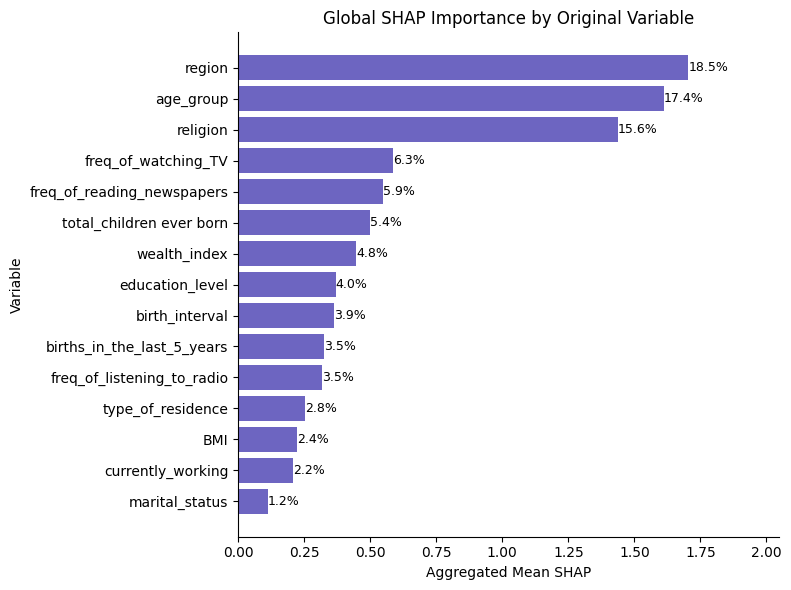

In [ ]:
top_n = 15
plot_df = aggregated_df.head(top_n)

plt.figure(figsize=(8, 6))

bars = plt.barh(
    plot_df["Feature"],
    plot_df["Mean_SHAP"],
    color="#534AB7",
    alpha=0.85
)

# Annotate each bar with % contribution
for bar, pct in zip(bars, plot_df["% Contribution"]):
    plt.text(
        bar.get_width() + 0.0002,        # slight offset from bar end
        bar.get_y() + bar.get_height() / 2,
        f"{pct}%",
        va="center", ha="left", fontsize=9
    )

plt.xlabel("Aggregated Mean SHAP")
plt.ylabel("Variable")
plt.title("Global SHAP Importance by Original Variable")
plt.gca().invert_yaxis()
plt.xlim(0, plot_df["Mean_SHAP"].max() * 1.2)   # extra space for labels
plt.spines[["top", "right"]].set_visible(False) if hasattr(plt, 'spines') else plt.gca().spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()